# Game Theory on Complex Networks
Playground to figure out network generation, update rules and simulations.

In [1]:
import networkx as nx 
import numpy as np
import random
import matplotlib.pyplot as plt

np.random.seed(13)

### 1. Network Generation
Let's try to implement the network generation as described by [Gómez-Gardeñes et al., 2006](http://dx.doi.org/10.1103/PhysRevE.73.056124)

In [2]:
def generate_mixed_network(N:int=1000, alpha:float=0.0, m:int=6, m0_frac:float=0.1) -> nx.Graph:
    m0 = int(N*m0_frac)
    G = nx.complete_graph(m0)  # initialise fully connected network with m0 nodes
    U_idx = np.arange(m0, N) # indices of N-m0 initially unconnected nodes
    G.add_nodes_from(U_idx)  # add the N-m0 unconnected nodes

    # we'll have to go through all N-m0 unconnected nodes, each selected randomly
    # let's do this by shuffeling the index list and go through the nodes in the
    # obtained random order
    np.random.shuffle(U_idx)

    for idx in U_idx:
        # create m links:
        for _ in range(m):
            # (re)compute node probs:
            E = G.number_of_edges()
            # with probability alpha select a uniformly random one of all nods
            # with probability 1-alpha select node via preferential attachment
            probs = np.array([(1.0-alpha)*val/(2*E - G.degree(idx)) + alpha*1/(N-1) for (node, val) in G.degree() if node != idx])
            #print(probs.sum())
            #print(probs.shape)
            node = np.random.choice(np.delete(np.arange(N), idx), p=probs)
            G.add_edge(idx, node)

    return G

50
233


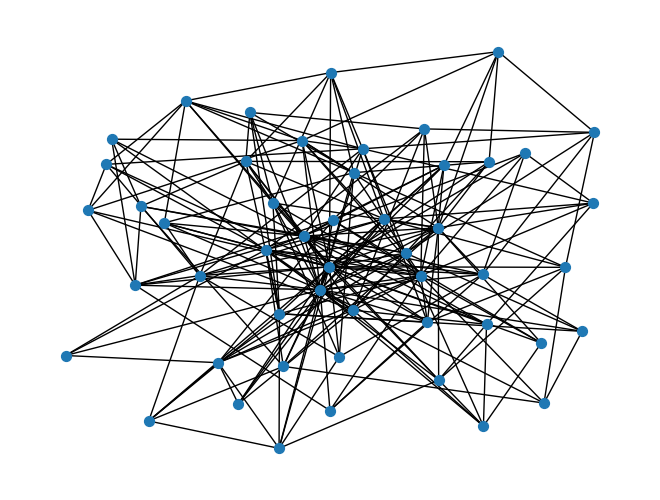

In [3]:
G = generate_mixed_network(N=50)
print(G.number_of_nodes())
print(G.number_of_edges())
nx.draw(G, node_size=50)

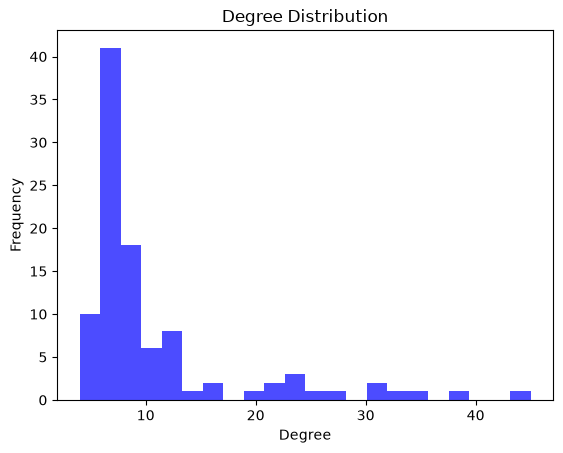

In [4]:
# plot degree distribution
G = generate_mixed_network(N=100)
degree_sequence = sorted([d for n, d in G.degree()], reverse=True) 
plt.hist(degree_sequence, bins=22, color='blue', alpha=0.7)
plt.title("Degree Distribution")    
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.show()

### Running the Ultimatum game

### Update rules